# Evaluation of Validation Set

Logan Wong

law3082

In [4]:
import sys
import os

# Add the DPAC program folder to path
dpac_path = '/home/stu5/s5/law3082/Courses/MLDD/Deep-Probability-Aggregation-Clustering/PAC_DPAC_program/'
if dpac_path not in sys.path:
    sys.path.append(dpac_path)

In [32]:
import torch
import numpy as np
import pandas as pd

# Model
import torch.nn as nn
from models import Network 

# Evaluation metrics
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

# Visualization
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
os.environ["CUDA_VISIBLE_DEVICES"]="6"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [20]:
# LOAD VALID
valid_embeddings_raw = np.load('data/valid_embeddings.npy')
valid_embeddings = torch.from_numpy(valid_embeddings_raw).float().to(device)
valid_metadata = pd.read_csv('data/valid_metadata.csv')
print(f"Valid: {valid_embeddings.shape[0]} embeddings, dim {valid_embeddings.shape[1]}")


Valid: 13417 embeddings, dim 768


In [22]:
# Define a Backbone for vectors
# original DPAC repo uses ResNet (which is for images)
# This is an MLP backbone to handle Twitter vectors
class TwitterBackbone(nn.Module):
    def __init__(self, input_dim=768, rep_dim=128):
        super().__init__()
        self.rep_dim = rep_dim # The Network class NEEDS this attribute
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, rep_dim)
        )
        
    def forward(self, x):
        return self.encoder(x)

In [21]:
model_save_path = 'models/event2012_DPAC_model.tar'

In [23]:
# Load the checkpoint file
checkpoint = torch.load(model_save_path, map_location=device)

# Extract parameters to rebuild the architecture
saved_num_events = checkpoint['num_events']
saved_hps = checkpoint['hps']

# Re-initialize backbone and model structure
loaded_backbone = TwitterBackbone(input_dim=768, rep_dim=128)
loaded_model = Network(loaded_backbone, loaded_backbone.rep_dim, class_dim=saved_num_events).to(device)

# Load the weights (the state_dict)
loaded_model.load_state_dict(checkpoint['model_state_dict'])

# Set to evaluation mode (turns off Dropout/BatchNorm updates)
loaded_model.eval()

print(f"Model loaded successfully from {model_save_path}")
print(f"Verified HPs used: {saved_hps}")

Model loaded successfully from models/event2012_DPAC_model.tar
Verified HPs used: {'lr': 0.0003, 'weight_decay': 0.0001, 'temp': 0.5}


/tmp/ipykernel_1113065/923246790.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_save_path, map_location=device)


In [26]:
# Inference (No gradients needed)
with torch.no_grad():
    # test_forward returns (features, probabilities)
    _, probs = loaded_model.test_forward(valid_embeddings)
    
    # Get cluster index with highest probability
    preds = torch.argmax(probs, dim=1).cpu().numpy()

# Get ground truth labels from metadata
y_true = valid_metadata['label'].values

print(f"Clustering finished for {len(preds)} tweets.")

Clustering finished for 13417 tweets.


In [31]:
# Calculate Metrics
nmi = normalized_mutual_info_score(y_true, preds)
ari = adjusted_rand_score(y_true, preds)

print(f"Validation Results")
print(f"NMI (Normalized Mutual Information): {nmi:.4f}")
print(f"ARI (Adjusted Rand Index): {ari:.4f}")

# NMI (Normalized Mutual Information): 0.3580
# ARI (Adjusted Rand Index): 0.0612

# NMI measures how much info is shared between my clusters and the true events. 
# For Event2012, an NMI above 0.40 is usually a good sign that the model has captured the main topics.
# ARI measures how many pairs of tweets are correctly grouped together or correctly separated. 
# An ARI above 0.20 is respectable for noisy Twitter data.

Validation Results
NMI (Normalized Mutual Information): 0.3580
ARI (Adjusted Rand Index): 0.0612


# Visualize

In [35]:
# Get latent features (z) for validation set
with torch.no_grad():
    # Use test_forward to get the normalized features 'x' (or 'z')
    z_valid, _ = loaded_model.test_forward(valid_embeddings)
    z_valid = z_valid.cpu().numpy()

# Run t-SNE
print("Running t-SNE...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
z_2d = tsne.fit_transform(z_valid)
print("DONE!")

Running t-SNE...


In [37]:
hps = {
    "lr":0.0003,
    "weight_decay":0.0001,
    "temp":0.5
}

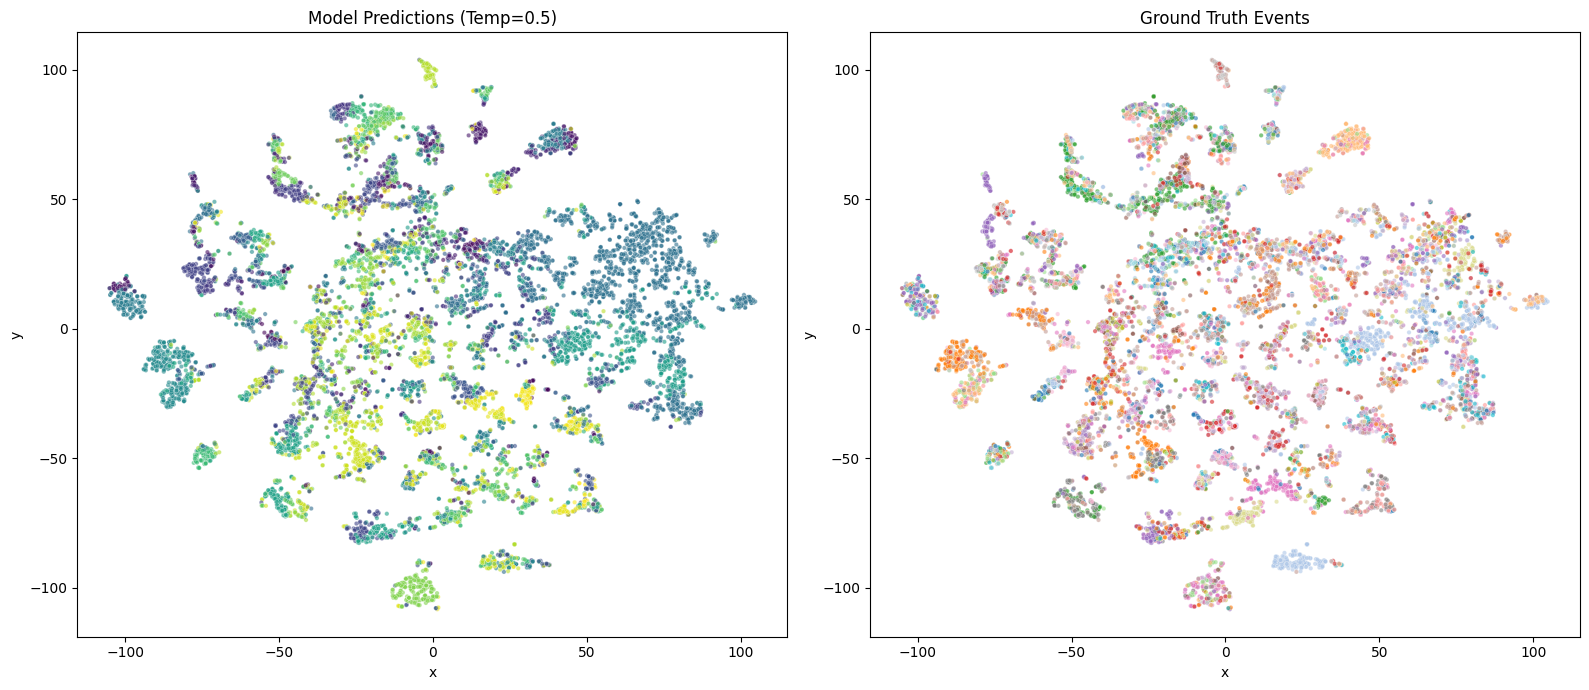

In [38]:
# DataFrame for easy plotting
plot_df = pd.DataFrame({
    'x': z_2d[:, 0],
    'y': z_2d[:, 1],
    'Cluster': preds,          # model output
    'Event': y_true            # Ground truth
})

# Plotting
plt.figure(figsize=(16, 7))

# Plot 1: Model Clusters
plt.subplot(1, 2, 1)
sns.scatterplot(data=plot_df, x='x', y='y', hue='Cluster', palette='viridis', legend=False, s=10, alpha=0.6)
plt.title(f"Model Predictions (Temp={hps['temp']})")

# Plot 2: Actual Events
plt.subplot(1, 2, 2)
sns.scatterplot(data=plot_df, x='x', y='y', hue='Event', palette='tab20', legend=False, s=10, alpha=0.6)
plt.title("Ground Truth Events")

plt.tight_layout()
# plt.savefig("clustering_visualization.png")